# Cài đặt

In [1]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-y8g7ermt
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-y8g7ermt
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=8de0f1450a6ff442ab91c20cfe48ab595a39c55c61854130a9c2e349ef7dd033
  Stored in directory: /tmp/pip-ephem-wheel-cache-fjw1d0nh/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anhnguynduyhong/bird-dataset-splited")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/anhnguynduyhong/bird-dataset-splited


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anhnguynduyhong/birds-dataset-original")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/anhnguynduyhong/birds-dataset-original


# Cài đặt thư viện

In [2]:
import os
import clip
import torch
import numpy as np
import time
import pickle
from PIL import Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from tqdm import tqdm
from itertools import product
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import PredefinedSplit

# Load the model

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load('ViT-B/32', device)

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 352MiB/s]


# Load Dataset

In [4]:
train_dataset = ImageFolder(
    root="/kaggle/input/datasets/anhnguynduyhong/birds-dataset-original/train",
    transform=preprocess
)

val_dataset = ImageFolder(
    root="/kaggle/input/datasets/anhnguynduyhong/birds-dataset-original/val",
    transform=preprocess
)

test_dataset = ImageFolder(
    root="/kaggle/input/datasets/anhnguynduyhong/birds-dataset-original/test",
    transform=preprocess
)

In [5]:
print(train_dataset.class_to_idx)

{'ABBOTTS BOOBY': 0, 'ABYSSINIAN GROUND HORNBILL': 1, 'AFRICAN PIED HORNBILL': 2, 'AFRICAN PYGMY GOOSE': 3, 'ALPINE CHOUGH': 4, 'AMERICAN AVOCET': 5, 'AMERICAN BITTERN': 6, 'AMERICAN DIPPER': 7, 'AMERICAN PIPIT': 8, 'AMERICAN WIGEON': 9, 'ASHY STORM PETREL': 10, 'ASIAN GREEN BEE EATER': 11, 'ASIAN OPENBILL STORK': 12, 'AUCKLAND SHAQ': 13, 'AUSTRALASIAN FIGBIRD': 14, 'AZARAS SPINETAIL': 15, 'BANDED BROADBILL': 16, 'BAR-TAILED GODWIT': 17, 'BLACK BREASTED PUFFBIRD': 18, 'BLACK HEADED CAIQUE': 19, 'BLACK NECKED STILT': 20, 'BLACK VENTED SHEARWATER': 21, 'BLACK-THROATED SPARROW': 22, 'BLUE DACNIS': 23, 'BLUE GRAY GNATCATCHER': 24, 'BLUE GROSBEAK': 25, 'BLUE GROUSE': 26, 'BLUE HERON': 27, 'BLUE MALKOHA': 28, 'BLUE THROATED PIPING GUAN': 29, 'BREWERS BLACKBIRD': 30, 'BROWN CREPPER': 31, 'BROWN HEADED COWBIRD': 32, 'BUFFLEHEAD': 33, 'CABOTS TRAGOPAN': 34, 'CAMPO FLICKER': 35, 'CANVASBACK': 36, 'CASPIAN TERN': 37, 'CEDAR WAXWING': 38, 'CHESTNUT WINGED CUCKOO': 39, 'CHUKAR PARTRIDGE': 40, 'CLAR

# Rút trích đặc trưng

In [6]:
def get_features(dataset):
    all_features = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(DataLoader(dataset, batch_size=100)):
            features = model.encode_image(images.to(device))
            all_features.append(features)
            all_labels.append(labels)

    return torch.cat(all_features).cpu().numpy(), torch.cat(all_labels).cpu().numpy()

In [7]:
# Calculate the image features
start_train = time.time()
train_features, train_labels = get_features(train_dataset)
val_features, val_labels     = get_features(val_dataset)
test_features, test_labels   = get_features(test_dataset)
end_train = time.time()
feature_extraction_time = end_train - start_train
print(f"⏱️ Feature extraction time : {feature_extraction_time:.4f} seconds")

100%|██████████| 45/45 [00:37<00:00,  1.18it/s]

⏱️ Feature extraction time : 285.7264 seconds


# Feature dim

In [13]:
print(train_features.shape)

(24328, 512)


# Time feature extraction

In [19]:
image_path = "/kaggle/input/datasets/anhnguynduyhong/birds-dataset-original/train/AFRICAN PYGMY GOOSE/003.jpg"

# ===== LOAD IMAGE =====
image = Image.open(image_path)

# ===== LOAD MODEL CPU =====
model_cpu, preprocess = clip.load("ViT-B/32", device="cpu")

image_input_cpu = preprocess(image).unsqueeze(0)

# ===== LOAD MODEL GPU =====
device = "cuda" if torch.cuda.is_available() else "cpu"
model_gpu, _ = clip.load("ViT-B/32", device=device)

image_input_gpu = preprocess(image).unsqueeze(0).to(device)


# ================= CPU =================
# warm-up
for _ in range(5):
    with torch.no_grad():
        _ = model_cpu.encode_image(image_input_cpu)

# measure
cpu_times = []
for _ in range(20):
    start = time.time()
    with torch.no_grad():
        _ = model_cpu.encode_image(image_input_cpu)
    end = time.time()
    cpu_times.append(end - start)

cpu_avg = sum(cpu_times) / len(cpu_times)


# ================= GPU =================
if device == "cuda":
    # warm-up
    for _ in range(5):
        with torch.no_grad():
            _ = model_gpu.encode_image(image_input_gpu)

    gpu_times = []
    for _ in range(20):
        torch.cuda.synchronize()   # 🔥 rất quan trọng
        start = time.time()

        with torch.no_grad():
            _ = model_gpu.encode_image(image_input_gpu)

        torch.cuda.synchronize()   # 🔥 rất quan trọng
        end = time.time()

        gpu_times.append(end - start)

    gpu_avg = sum(gpu_times) / len(gpu_times)

else:
    gpu_avg = None


# ===== RESULT =====
print(f"⏱️ CPU avg time: {cpu_avg:.6f} sec/image")

if gpu_avg:
    print(f"🚀 GPU avg time: {gpu_avg:.6f} sec/image")
    print(f"⚡ Speedup: {cpu_avg / gpu_avg:.2f}x faster")
else:
    print("⚠️ No GPU available")

⏱️ CPU avg time: 0.083405 sec/image
🚀 GPU avg time: 0.007038 sec/image
⚡ Speedup: 11.85x faster


# GridSearch

In [9]:
# Giả định bạn đã trích xuất đặc trưng (Feature Extraction) xong và đang có dạng mảng (Numpy Array):
X_train, y_train = train_features, train_labels
X_val, y_val = val_features, val_labels

# --- BƯỚC 1: TẠO BỘ CHIA DỮ LIỆU CỐ ĐỊNH (PREDEFINED SPLIT) ---

# 1.1 Gộp tập Train và Val lại thành một tập chung
X_combined = np.vstack((X_train, X_val))
y_combined = np.concatenate((y_train, y_val))

# 1.2 Tạo mảng đánh dấu (test_fold)
# Quy tắc của PredefinedSplit: Index mang giá trị -1 là Train, giá trị 0 là Val
test_fold = np.concatenate([
    np.full(X_train.shape[0], -1),  # Gán toàn bộ data từ folder train thành -1
    np.full(X_val.shape[0], 0)      # Gán toàn bộ data từ folder val thành 0
])

In [10]:
# 1.3 Khởi tạo bộ chia
ps = PredefinedSplit(test_fold)

# --- BƯỚC 2: ĐƯA VÀO GRIDSEARCH CV ---

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt"],
    "bootstrap": [True]
}

rf = RandomForestClassifier(n_jobs=-1, random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=ps,             
    scoring="accuracy",
    verbose=3,
    n_jobs=-1
)

grid.fit(train_features, train_labels)


Fitting 1 folds for each of 16 candidates, totalling 16 fits
[CV 1/1] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.843 total time= 2.2min
[CV 1/1] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=100;, score=0.841 total time= 2.1min
[CV 1/1] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=10, n_estimators=100;, score=0.841 total time= 2.1min
[CV 1/1] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.903 total time= 7.1min


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])),
             estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [10, 20],
                         'max_features': ['sqrt'], 'min_samples_leaf': [1, 5],
                         'min_samples_split': [2, 10],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=3)

In [11]:
print(f"\nTham số tốt nhất tìm được: {grid.best_params_}")
print(f"Độ chính xác trên tập Validation cố định: {grid.best_score_:.4f}")


Tham số tốt nhất tìm được: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Độ chính xác trên tập Validation cố định: 0.9025
[CV 1/1] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.863 total time= 4.4min
[CV 1/1] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=10, n_estimators=200;, score=0.862 total time= 4.2min
[CV 1/1] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=100;, score=0.884 total time= 3.0min
[CV 1/1] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=5, min_samples_split=10, n_estimators=100;, score=0.884 total time= 3.0min
[CV 1/1] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200;, score=0.861 total time= 4.4min
[CV 1/1] END bootstrap=Tru

# Train model

In [13]:
print("Step 2: Train final model...")

start_train = time.time()

best_params = grid.best_params_

final_model = RandomForestClassifier(
    **best_params,        
    n_jobs=-1,
    random_state=42
)

final_model.fit(train_features, train_labels)

end_train = time.time()

train_time = end_train - start_train
print(f"⏱️ Train time: {train_time:.4f} seconds")


Step 2: Train final model...
⏱️ Train time: 108.8887 seconds


# Model size

In [14]:
import joblib
model_name = "CLIP_RandomForest_model_original.pkl"
joblib.dump(final_model, model_name)

['CLIP_RandomForest_model_original.pkl']

In [15]:
with open(model_name, "wb") as f:
    pickle.dump(final_model, f)

import os
model_size = os.path.getsize(model_name) / (1024 * 1024)
print(f"💾 Model size: {model_size:.4f} MB")

💾 Model size: 1805.6805 MB


# Thời gian dự đoán trên 1 feature

In [17]:
from joblib import load
# ===== LOAD MODEL RANDOM FOREST =====
rf_model = load(model_name)
img_path = "/kaggle/input/datasets/anhnguynduyhong/birds-dataset-original/test/ALPINE CHOUGH/008.jpg"  
image = Image.open(img_path).convert("RGB")

# ===== EXTRACT FEATURE =====
image_input = preprocess(image).unsqueeze(0).to(device)

with torch.no_grad():
    image_features = model.encode_image(image_input)
    image_features = image_features.cpu().numpy()

# ===== MEASURE INFERENCE TIME (CHỈ MODEL) =====
start_inf = time.time()

pred = rf_model.predict(image_features)

end_inf = time.time()

# ===== OUTPUT =====
print("Prediction:", pred[0])
print(f"⚡ Inference time (RF only): {end_inf - start_inf:.6f} seconds")

Prediction: 4
⚡ Inference time (RF only): 0.045465 seconds


In [18]:
start_inf = time.time()

preds = final_model.predict(test_features)

end_inf = time.time()

inf_time = end_inf - start_inf
print(f"⚡ Inference time (CPU): {inf_time:.4f} seconds")
print(f"⚡ Time per sample: {inf_time / len(test_features):.6f} sec/sample")

⚡ Inference time (CPU): 0.2541 seconds
⚡ Time per sample: 0.000057 sec/sample


# Test model

In [19]:
predictions = final_model.predict(test_features)
accuracy = np.mean((test_labels == predictions).astype(float)) * 100

print(f"\n🔥 Test Accuracy = {accuracy:.2f}%")


🔥 Test Accuracy = 90.38%


In [20]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(test_labels, predictions))
print(classification_report(test_labels, predictions))

Accuracy: 0.9037600716204118
              precision    recall  f1-score   support

           0       0.83      0.66      0.73        29
           1       0.84      0.93      0.89        29
           2       0.76      0.97      0.85        30
           3       0.96      0.86      0.91        29
           4       0.93      0.93      0.93        27
           5       0.96      0.93      0.95        29
           6       0.96      1.00      0.98        27
           7       0.80      0.93      0.86        30
           8       0.88      0.97      0.92        29
           9       0.87      0.87      0.87        30
          10       0.68      0.63      0.66        30
          11       0.94      1.00      0.97        33
          12       0.84      0.87      0.85        30
          13       0.95      0.70      0.81        30
          14       0.90      0.90      0.90        30
          15       0.96      0.96      0.96        27
          16       0.97      1.00      0.98        3

===== METRICS =====
Accuracy : 0.9038
Precision: 0.9096
Recall   : 0.9036
F1-score : 0.9040

===== CONFUSION MATRIX =====
[[19  0  0 ...  0  0  0]
 [ 0 27  1 ...  0  0  0]
 [ 0  1 29 ...  0  0  0]
 ...
 [ 0  0  0 ... 27  0  0]
 [ 0  0  0 ...  0 30  0]
 [ 0  0  0 ...  0  0 25]]


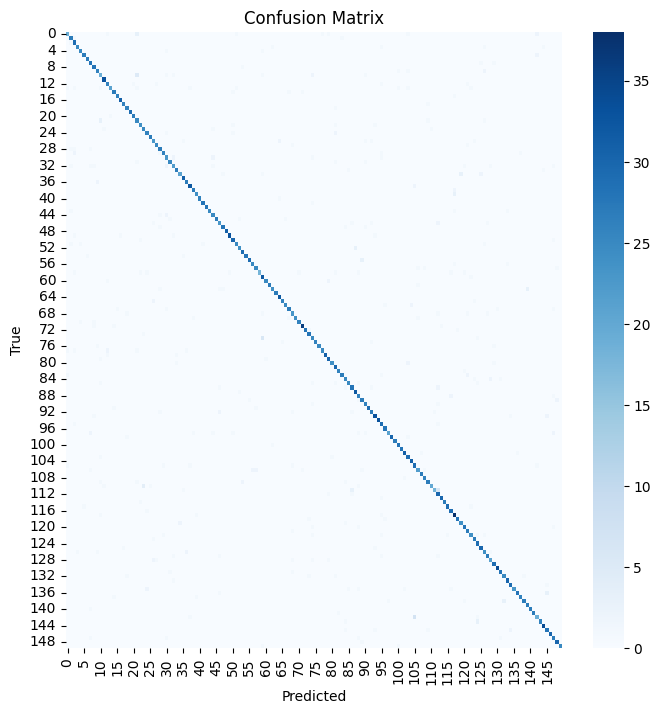

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ===== Predict =====
preds = final_model.predict(test_features)

# ===== 4 metrics =====
acc = accuracy_score(test_labels, preds)
precision = precision_score(test_labels, preds, average="macro")
recall = recall_score(test_labels, preds, average="macro")
f1 = f1_score(test_labels, preds, average="macro")

print("===== METRICS =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# ===== Confusion Matrix =====
cm = confusion_matrix(test_labels, preds)

print("\n===== CONFUSION MATRIX =====")
print(cm)   # in dạng số

# ===== Vẽ đẹp =====
plt.figure(figsize=(8, 8))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [22]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import clip
from torchvision import datasets
from joblib import load

# ===== LOAD CLIP =====
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess = clip.load("ViT-B/32", device=device)

# ===== LOAD RF =====
rf_model = load(model_name)

# ===== DATASET =====
test_dir = "/kaggle/input/datasets/anhnguynduyhong/birds-dataset-original/test"
test_dataset = datasets.ImageFolder(root=test_dir, transform=preprocess)

# 🔥 CLASS NAME
classes = test_dataset.classes

In [24]:
import random
import numpy as np

def build_class_to_image(dataset, classes, max_per_class=100):
    class_indices = {i: [] for i in range(len(classes))}

    # gom index theo class (chỉ lấy tối đa 100 mỗi class)
    for idx in range(len(dataset)):
        _, label = dataset[idx]

        if len(class_indices[label]) < max_per_class:
            class_indices[label].append(idx)

        # tối ưu: dừng sớm nếu đủ hết class
        if all(len(v) >= 1 for v in class_indices.values()):
            # vẫn tiếp tục để đủ 100 nếu muốn, nhưng có thể break nếu cần nhanh
            pass

    class_to_image = {}

    for label, indices in class_indices.items():
        if len(indices) == 0:
            continue

        # 🔥 chọn random 1 ảnh trong tối đa 100 ảnh đầu
        rand_idx = random.choice(indices)

        img, _ = dataset[rand_idx]

        # unnormalize (giống code của bạn)
        img_vis = img.permute(1, 2, 0).cpu().numpy()
        img_vis = (img_vis * np.array([0.2686, 0.2613, 0.2758]) +
                   np.array([0.4815, 0.4578, 0.4082]))
        img_vis = np.clip(img_vis, 0, 1)

        class_to_image[label] = img_vis

    return class_to_image

In [26]:
correct_imgs, correct_info = [], []
wrong_imgs, wrong_info = [], []
class_to_image = build_class_to_image(train_dataset, classes)
# ===== SHUFFLE =====
all_indices = list(range(len(test_dataset)))
random.shuffle(all_indices)

with torch.no_grad():
    for idx in all_indices:
        img, label = test_dataset[idx]

        input_img = img.unsqueeze(0).to(device)

        # ===== CLIP FEATURE =====
        feat = clip_model.encode_image(input_img)
        feat = feat.cpu().numpy()

        # ===== RF PREDICT =====
        pred = rf_model.predict(feat)[0]

        # ===== UNNORMALIZE =====
        img_vis = img.permute(1, 2, 0).cpu().numpy()
        img_vis = (img_vis * np.array([0.2686, 0.2613, 0.2758]) +
                   np.array([0.4815, 0.4578, 0.4082]))
        img_vis = np.clip(img_vis, 0, 1)

        # ===== PHÂN LOẠI =====
        if pred == label:
            if len(correct_imgs) < 25:
                correct_imgs.append(img_vis)
                correct_info.append((pred, label))
        else:
            if len(wrong_imgs) < 25:
                wrong_imgs.append(img_vis)
                wrong_info.append((pred, label))

        # ===== DỪNG =====
        if len(correct_imgs) >= 25 and len(wrong_imgs) >= 25:
            break

In [27]:
# ===== SHOW =====
def show_grid(images, info, title):
    if len(images) == 0:
        print(f"Không có ảnh: {title}")
        return

    plt.figure(figsize=(12, 12))

    for i in range(len(images)):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i])
        plt.axis("off")

        pred, label = info[i]
        color = "green" if pred == label else "red"

        plt.title(
            f"P: {classes[pred]}\nT: {classes[label]}",
            fontsize=8,
            color=color
        )

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

In [28]:
def show_predicted_class_images(images, info, class_to_image, title):
    n = min(len(images), 25)
    cols = 5
    rows = 2 * ((n + cols - 1) // cols)

    plt.figure(figsize=(15, 3 * rows))

    for i in range(n):
        pred, label = info[i]

        block_row = (i // cols) * 2
        col = i % cols

        # ===== HÀNG LẺ (ẢNH INPUT) =====
        plt.subplot(rows, cols, block_row * cols + col + 1)
        plt.imshow(images[i])
        plt.axis("off")

        plt.title(
            f"GT: {classes[label]}\nPred: {classes[pred]}",
            fontsize=9,
            color="red" if pred != label else "green"
        )

        # ===== HÀNG CHẴN (ẢNH CLASS PRED) =====
        pred_img = class_to_image[pred]

        plt.subplot(rows, cols, (block_row + 1) * cols + col + 1)
        plt.imshow(pred_img)
        plt.axis("off")

        plt.title(
            f"{classes[pred]}",
            fontsize=10,
            color="blue"
        )

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_55/1937366478.py:24: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


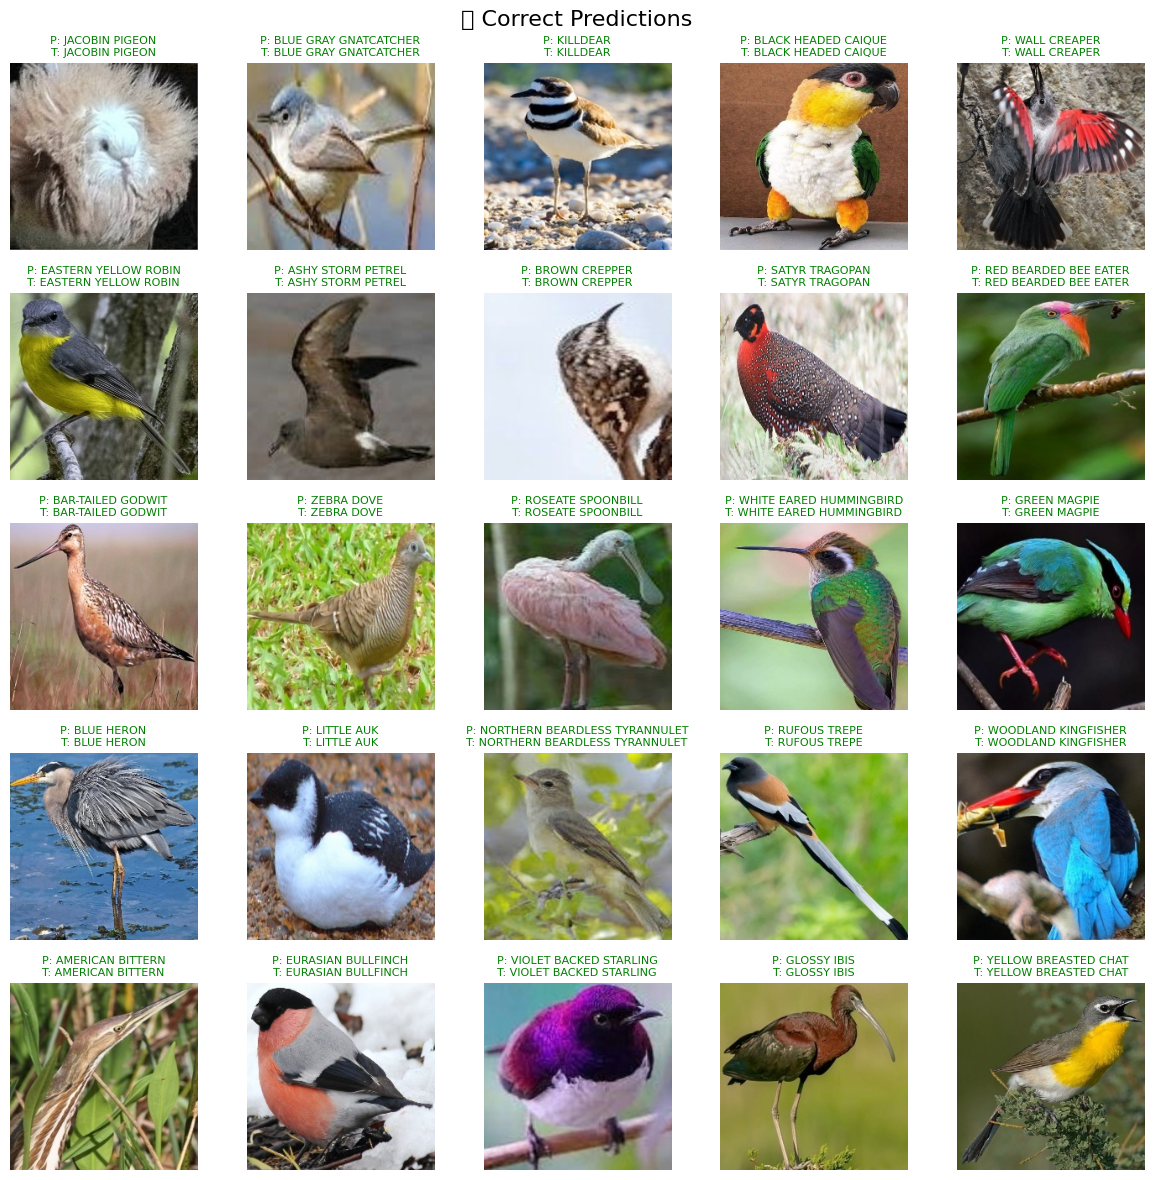

/tmp/ipykernel_55/2362896236.py:39: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


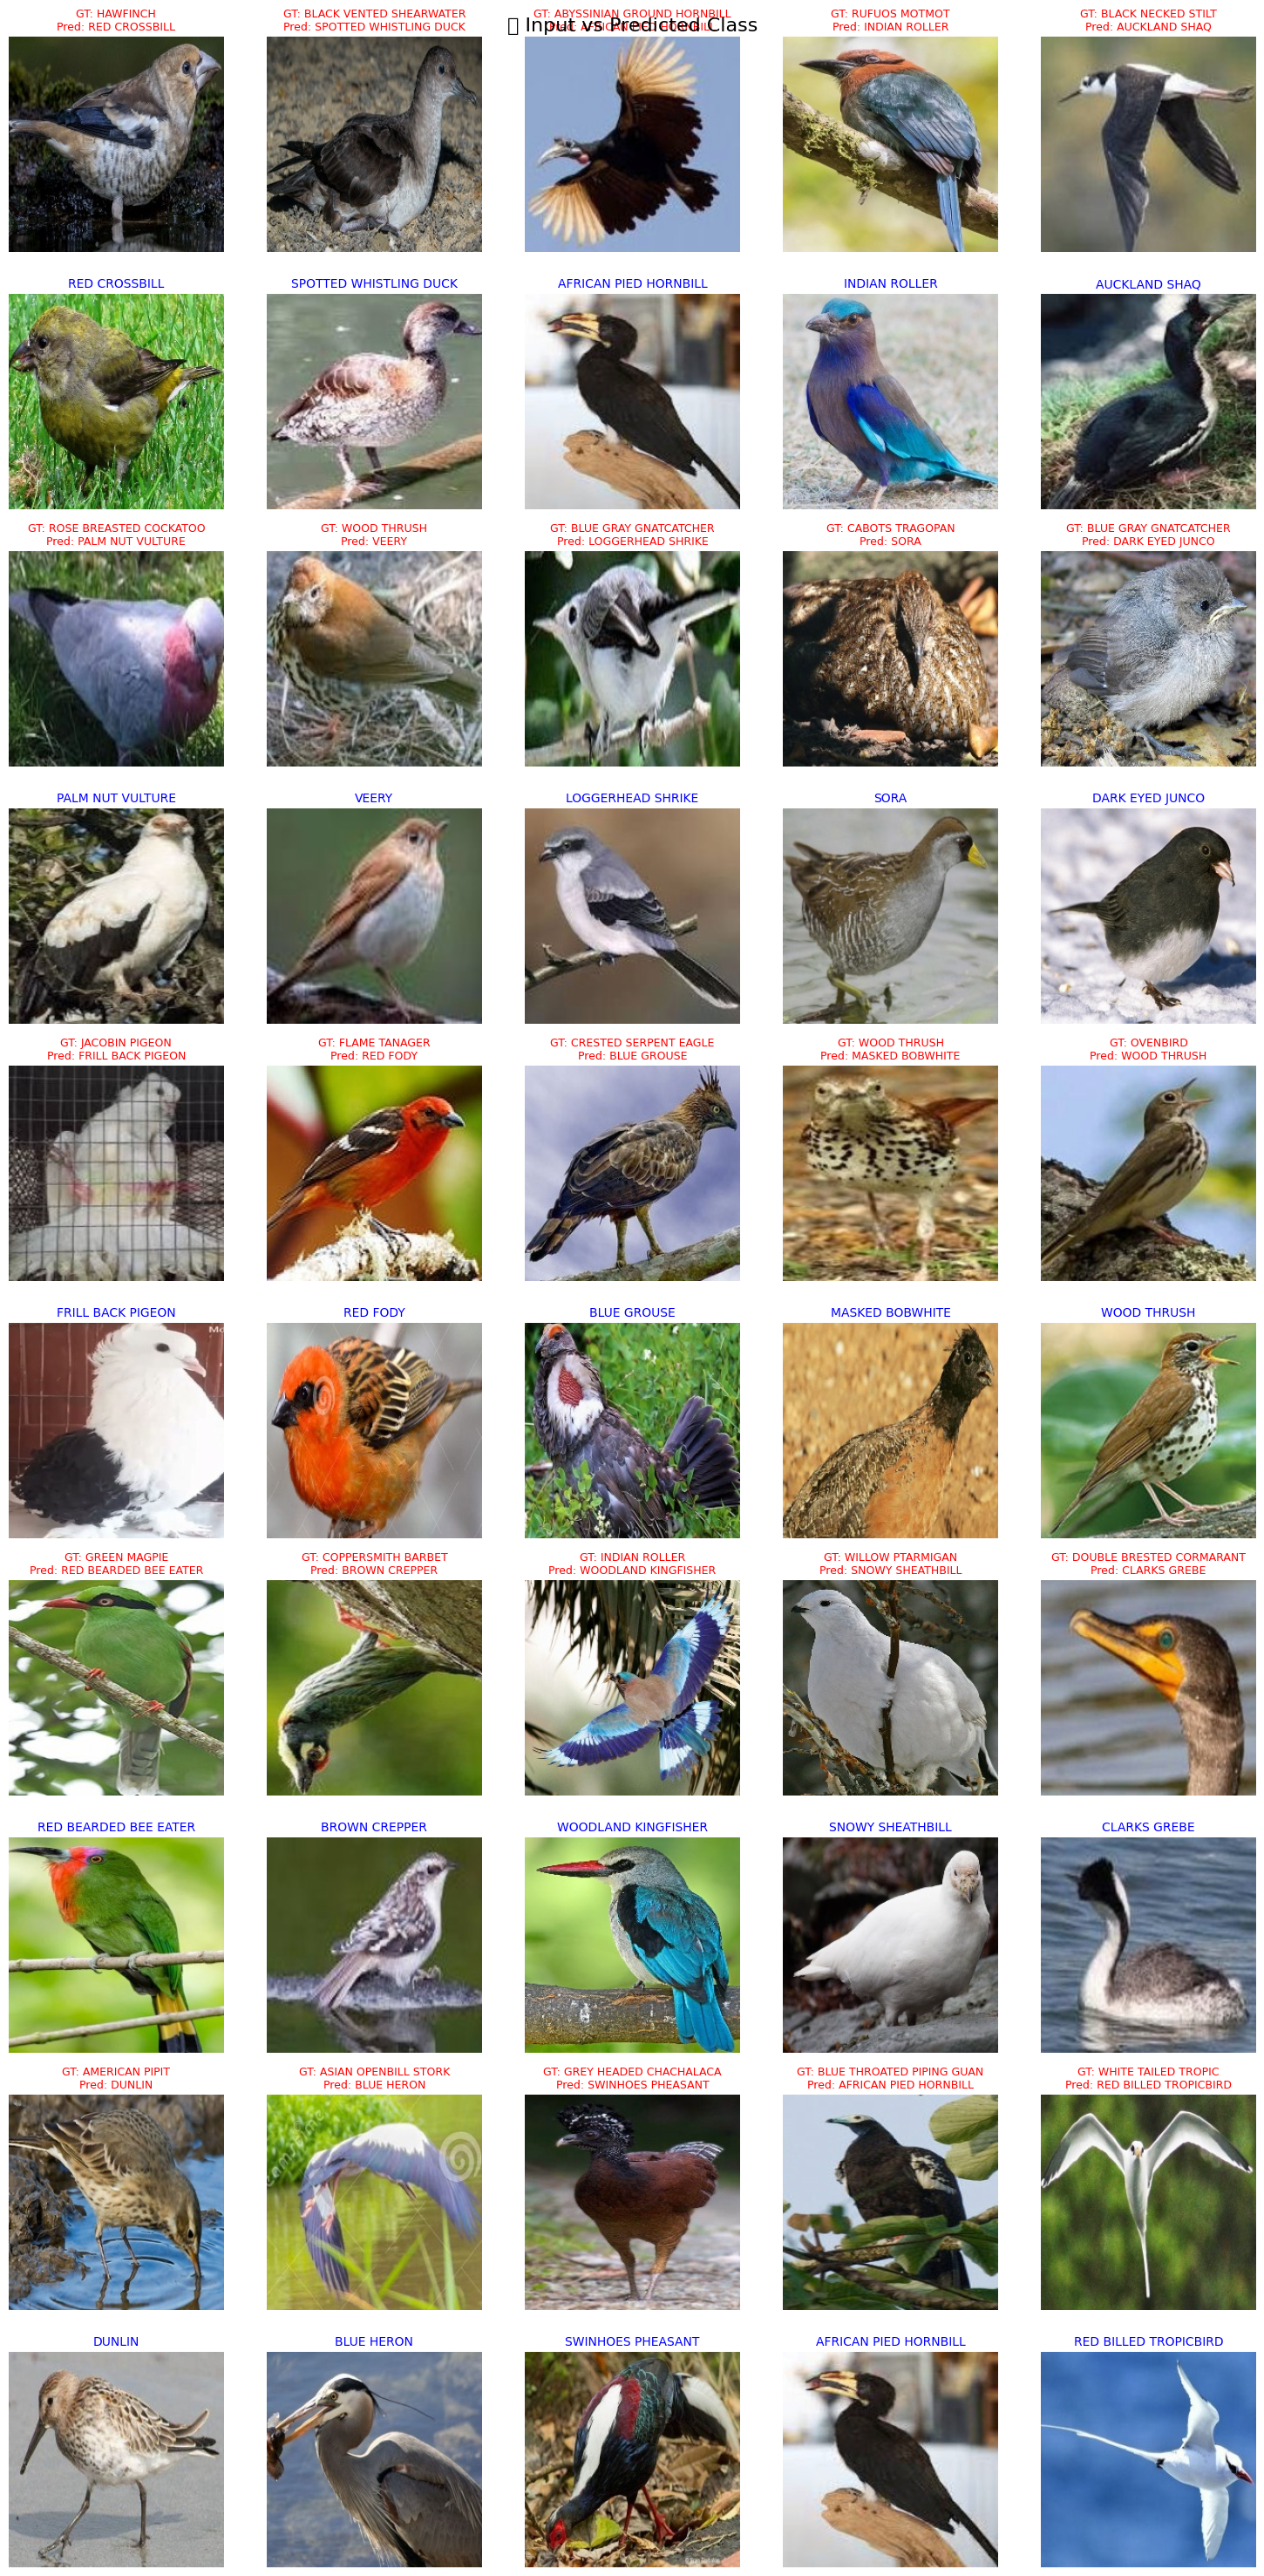

In [29]:
# ===== RUN =====
show_grid(correct_imgs, correct_info, "✅ Correct Predictions")
show_predicted_class_images(
    wrong_imgs,
    wrong_info,
    class_to_image,
    "❌ Input vs Predicted Class"
)